# RB EDA 02 — Distributions & Target Stability

**Stage 6 (PROJECT_PLAN §3 `[6] eda`).** Shape of the target/features and how well season *N* predicts season *N+1*. Same shared library (`position_predictor.eda.analyze`) as the `run_eda.py` script; the notebook only renders.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parents[2] if Path.cwd().name == "rb" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from IPython.display import Image, display
from position_predictor.utils.config import Config
from position_predictor.eda.analyze import run_eda

cfg = Config.load(str(ROOT / "config" / "football_rb.yaml"))
# Compute every EDA table from the shared library + (re)write the reports artifacts.
tables = run_eda(cfg, write=True)
RESULTS = ROOT / "reports" / "results"
FIGURES = ROOT / "reports" / "figures"
print("player-seasons:", int(tables["universe"]["n_player_seasons"].sum()))

player-seasons: 4200


## 1. Distributions of the target & key features
`ppg`/`ppr_points`/volume are right-skewed with a zero/low mass (committee & injured backs) — which argues for **rank-based** evaluation (Spearman/NDCG/Precision@k) and tree models that handle skew and raw NaN natively (§7–8).

In [2]:
display(tables["distributions"].round(3))

,column,n,mean,std,skew,min,p05,p25,p50,p75,p95,max,pct_zero
0,ppg,4200,6.442,5.343,1.184,-2.800,0.633,2.271,4.814,9.420,17.086,32.393,0.013
1,target_ppg_next,2975,7.024,5.580,1.078,-0.200,0.800,2.596,5.400,10.394,17.989,32.393,0.012
2,ppr_points,4200,74.691,83.835,1.460,-2.800,1.100,10.900,40.700,115.600,246.910,481.100,0.013
3,touches,4200,89.633,102.079,1.290,0.000,2.000,12.000,44.000,140.000,310.000,457.000,0.011
4,carries,4200,73.794,89.832,1.360,0.000,0.000,6.000,33.000,114.000,272.000,416.000,0.077
5,targets,4200,20.100,21.990,1.597,0.000,0.000,3.000,12.000,29.000,66.000,142.000,0.073
6,yards_per_carry,3875,3.817,1.847,2.235,-12.000,1.000,3.030,3.880,4.558,6.000,29.000,0.017
7,snap_share,1915,0.305,0.198,0.705,0.010,0.052,0.146,0.259,0.440,0.683,0.964,0.000
8,age_at_season_start,4200,26.129,2.884,0.788,20.616,22.335,23.943,25.618,27.857,31.629,38.708,0.000
9,games,4200,9.137,5.232,-0.130,1.000,1.000,4.000,9.000,14.000,16.000,17.000,0.000


## 2. Year-over-year predictability (the must-beat signal)
Each row's season-*N* `ppg` is aligned with its observed *N+1* `target_ppg_next`, so each season's rows are the N→N+1 pairs. `persistence_mae` is the §7.1 **persistence baseline** error (predict next = this). `season = -1` pools all pairs.

In [3]:
st = tables["target_stability"]
display(st)
pooled = st[st["season"] == -1].iloc[0]
print(f"POOLED  Spearman={pooled.spearman:.3f}  Pearson={pooled.pearson:.3f}  "
      f"persistence MAE={pooled.persistence_mae:.2f} PPG  (n={int(pooled.n_pairs)})")

,season,n_pairs,spearman,pearson,persistence_mae,persistence_rmse
0,1999,118,0.611579,0.719196,3.269591,4.421260
1,2000,114,0.620800,0.720579,3.178666,4.613593
2,2001,116,0.704792,0.806682,2.708517,3.810386
3,2002,122,0.686359,0.819988,2.639821,3.670356
4,2003,131,0.701694,0.719565,3.129108,4.413507
5,2004,127,0.653083,0.788097,2.753982,3.845635
6,2005,124,0.628305,0.715063,3.138551,4.247452
7,2006,106,0.722083,0.759890,2.935455,4.028711
8,2007,120,0.600229,0.668766,3.195180,4.429300
9,2008,125,0.664340,0.684560,3.359225,4.317005


POOLED  Spearman=0.660  Pearson=0.712  persistence MAE=3.16 PPG  (n=2975)


## 3. Regression to the mean
Bucket by season-*N* PPG quintile and look at mean season-*N+1* PPG: high buckets fall toward the grand mean, low buckets rise — the basis of the §7.1 `mean_reversion` baseline. `shrink` = share of distance-from-mean erased next season.

In [4]:
display(tables["regression_to_mean"].round(2))

,ppg_bucket,n,mean_ppg_n,mean_ppg_next,grand_mean_next,shrink
0,0,595,1.42,3.17,7.02,0.31
1,1,595,3.47,4.29,7.02,0.23
2,2,596,6.04,5.92,7.02,-0.12
3,3,594,9.77,8.00,7.02,0.65
4,4,595,16.37,13.75,7.02,0.28


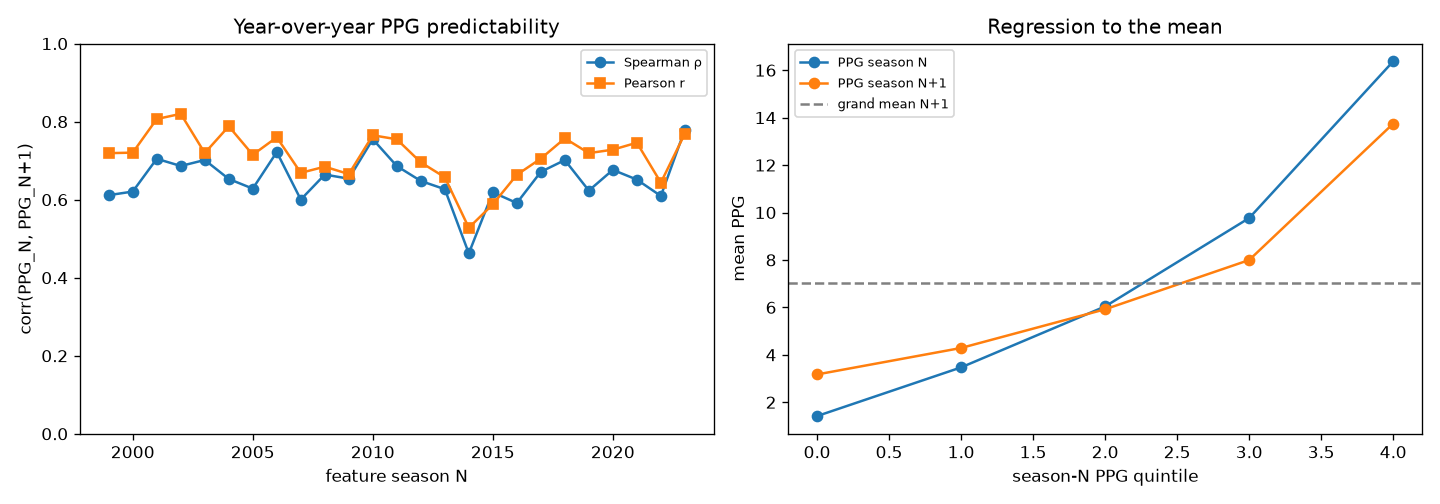

In [5]:
display(Image(str(FIGURES / "eda_football_rb_stability.png")))

### Findings
- Year-over-year PPG is strongly autocorrelated (pooled Spearman ≈0.66) — last season is a genuine signal, so persistence/smoothed-history are real must-beat baselines for Stage 8.
- The persistence baseline is off by ≈3 PPG on average; beating that (and the market benchmark) is the bar.
- Clear mean reversion in the tails motivates the `mean_reversion` baseline and shrinkage in the models.
- Right-skew + zero mass confirm rank metrics over raw-PPG error as the headline objective.